# Imports and Reading data

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

In [14]:
df = pd.read_csv('STO-const_decay-10k.csv')

# Data understanding

In [15]:
df.shape

# 10000 rows and 5 columns as expected

(10000, 5)

In [16]:
df.head(5)

,optimizer_gain,dither_amplitude,dither_frequency,converged,convergence_time
0,0.001795,0.409215,0.762317,0,NaN
1,0.001567,0.457554,0.652944,0,NaN
2,0.082227,0.146464,0.618753,0,NaN
3,0.087334,0.482795,0.463045,0,NaN
4,0.039862,0.479012,0.594150,1,11.82


In [17]:
df.dtypes

optimizer_gain      float64
dither_amplitude    float64
dither_frequency    float64
converged             int64
convergence_time    float64
dtype: object

# Data preparation

In [18]:
df.isna().sum()

# only the convergence_time has duplicated values(2843) so we do not need to drop any rows

optimizer_gain         0
dither_amplitude       0
dither_frequency       0
converged              0
convergence_time    2843
dtype: int64

# Feature understanding

Text(0, 0.5, 'Counts')

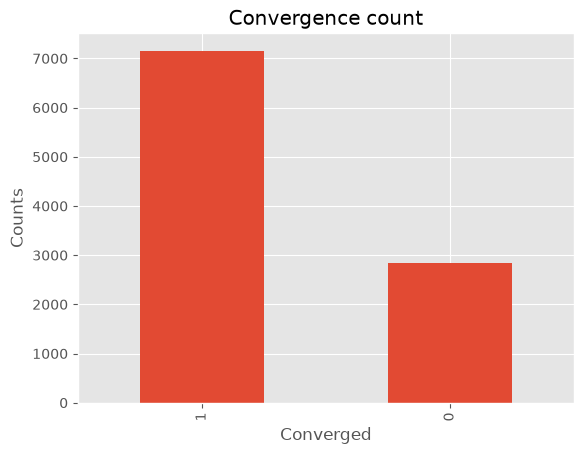

In [19]:
cv = df['converged'].value_counts().head(10).plot(kind = 'bar', title = 'Convergence count')

cv.set_xlabel('Converged')
cv.set_ylabel('Counts')

# More than 70% converged. I think this is a healthy spread as we care more about the converged combinations

Text(0, 0.5, 'Frequency')

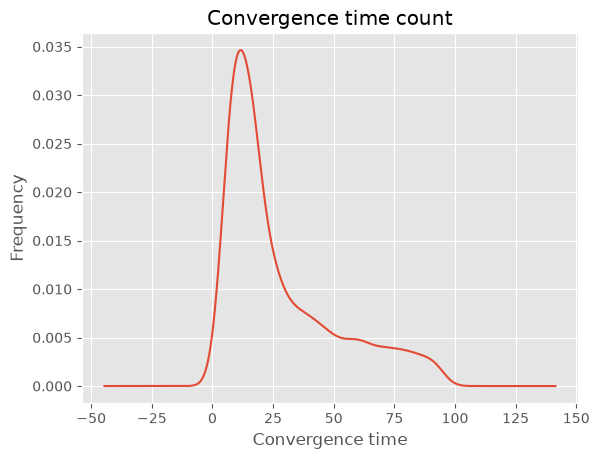

In [20]:
ct = df['convergence_time'].plot(kind = 'kde',
                title = 'Convergence time count')
ct.set_xlabel('Convergence time')
ct.set_ylabel('Frequency')

# Many combinations lead to convergence time < 12.5 seconds, which is really impressive

In [21]:
sum(df['convergence_time'] < 10)

# There are 1560 out of 10000 combinations that has the convergence_time < 10, which is extremely good

1560

In [22]:
sum(df['convergence_time'] < 5)

# 259 combinations have convergence time < 5. I see potential.


259

# Feature relationships

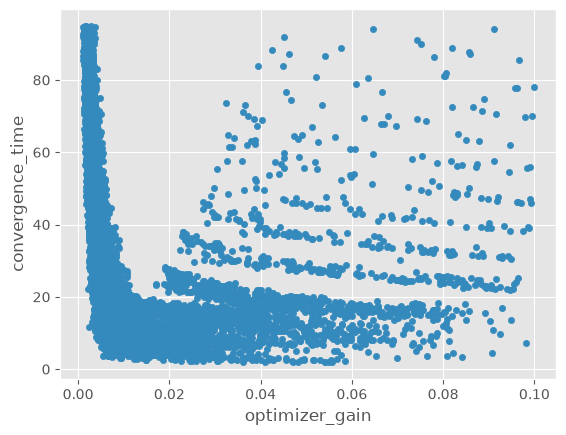

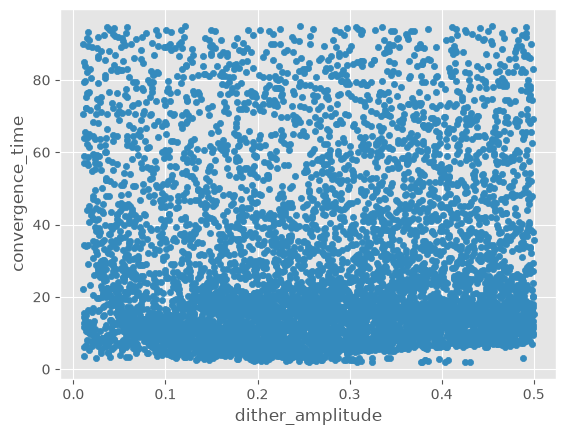

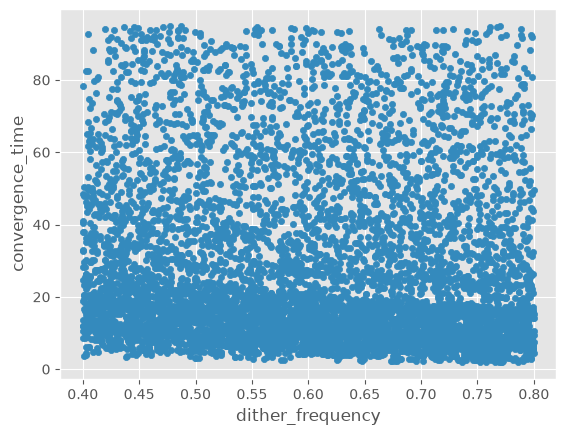

In [23]:
for i in range (df.shape[1] - 2):
    df.plot(kind = 'scatter',
            x = i,
            y = 'convergence_time')
    plt.show()


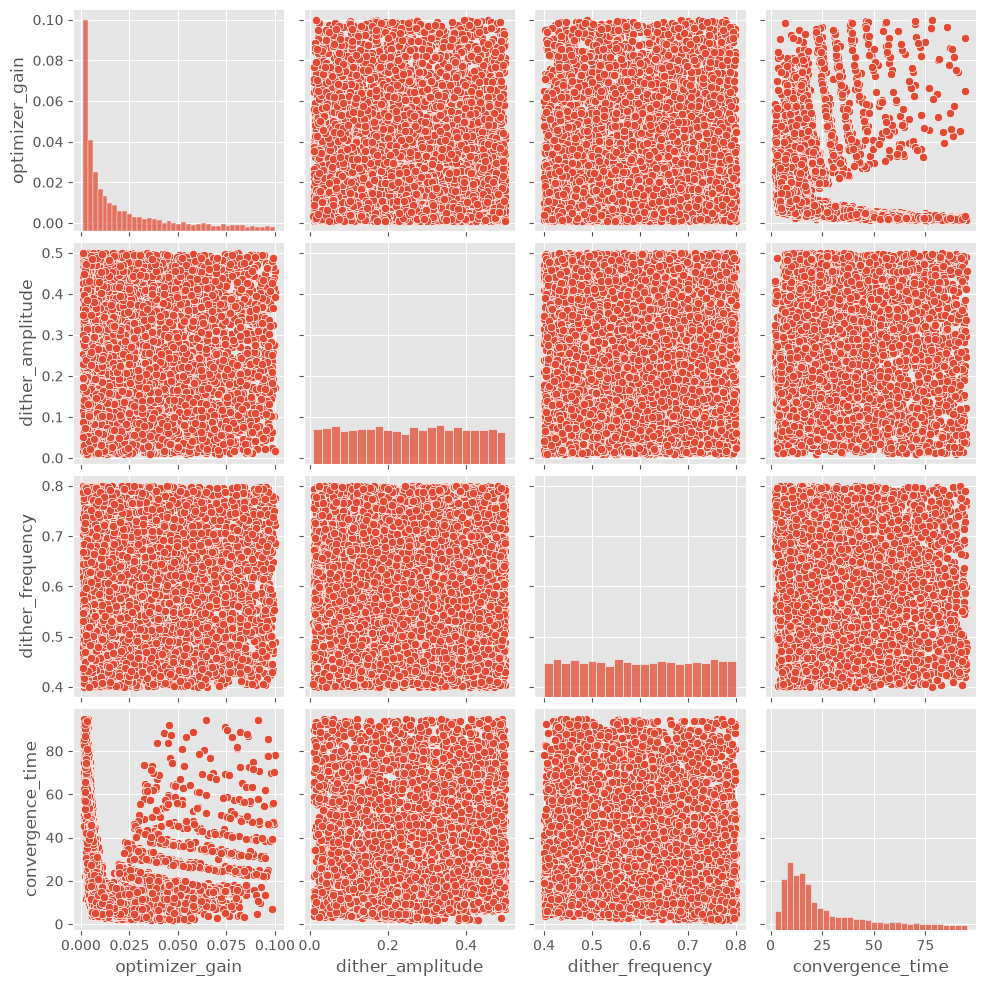

In [24]:
sns.pairplot(df,
             vars = ['optimizer_gain','dither_amplitude','dither_frequency', 'convergence_time'])
plt.show()


<Axes: >

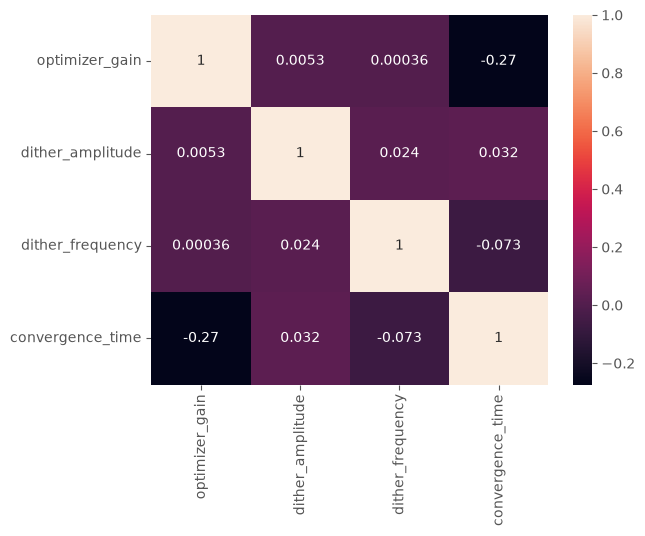

In [25]:
sns.heatmap(df.drop(columns = 'converged').corr(), annot = True)


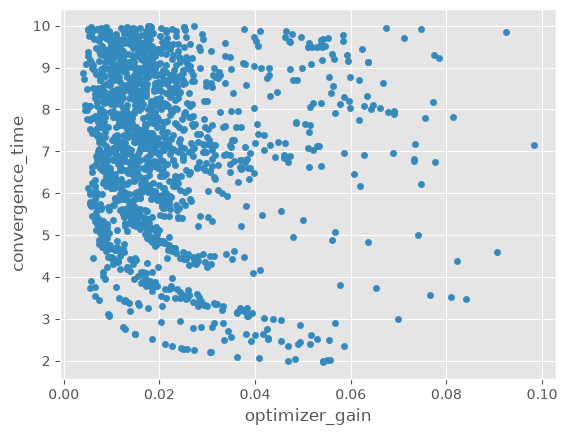

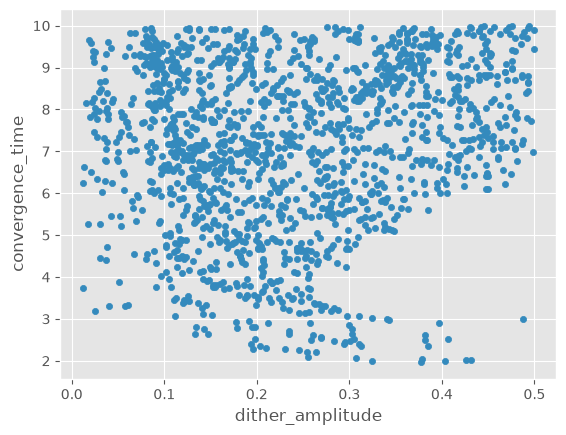

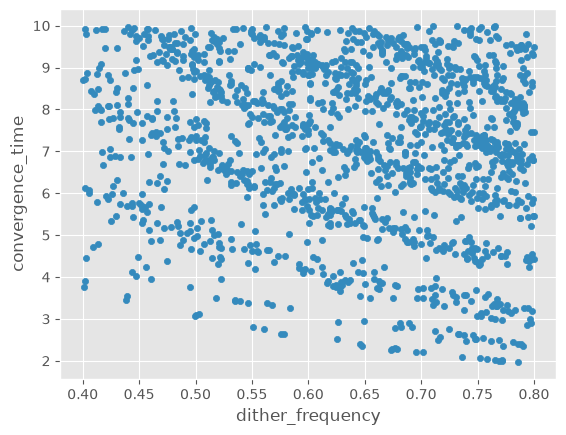

In [26]:
dfcut = df[df['convergence_time'] < 10]
for i in range (dfcut.shape[1] - 2):
    dfcut.plot(kind = 'scatter',
            x = i,
            y = 'convergence_time')
    plt.show()


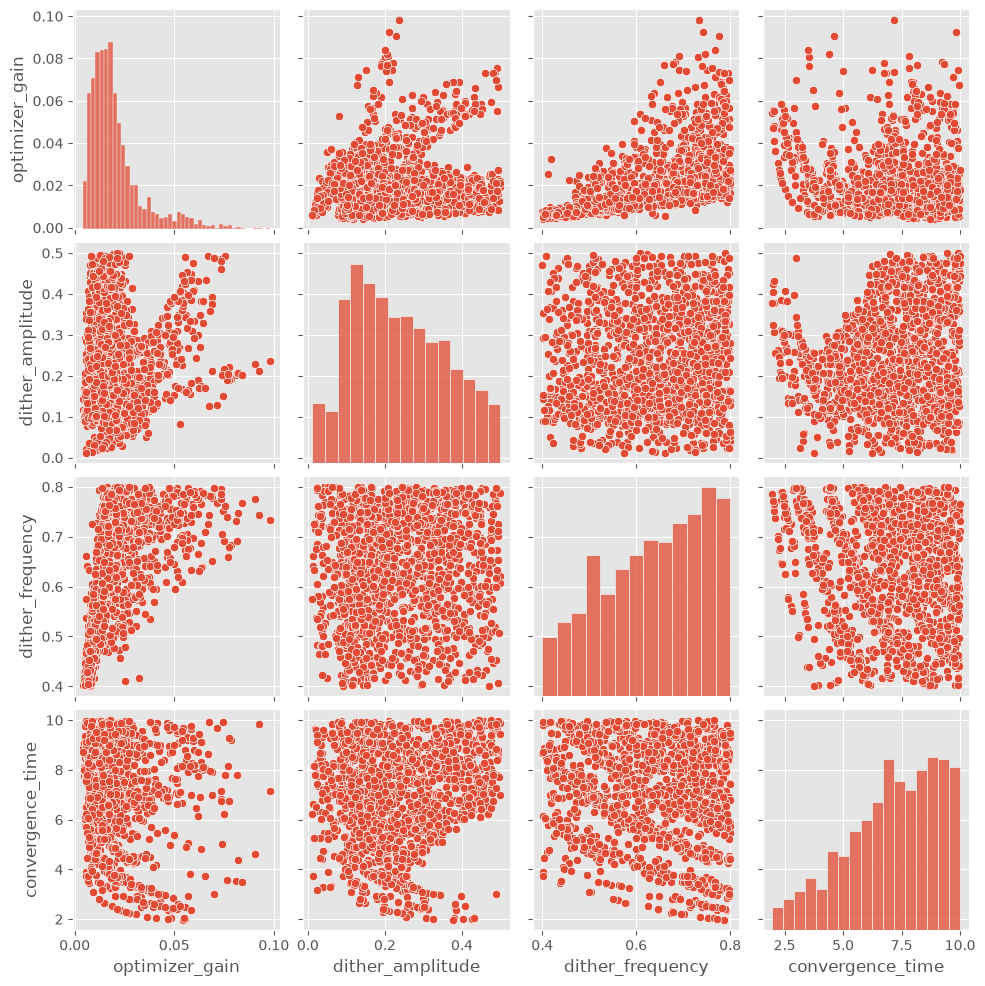

In [27]:
sns.pairplot(dfcut,
             vars = ['optimizer_gain','dither_amplitude','dither_frequency', 'convergence_time'])
plt.show()


<Axes: >

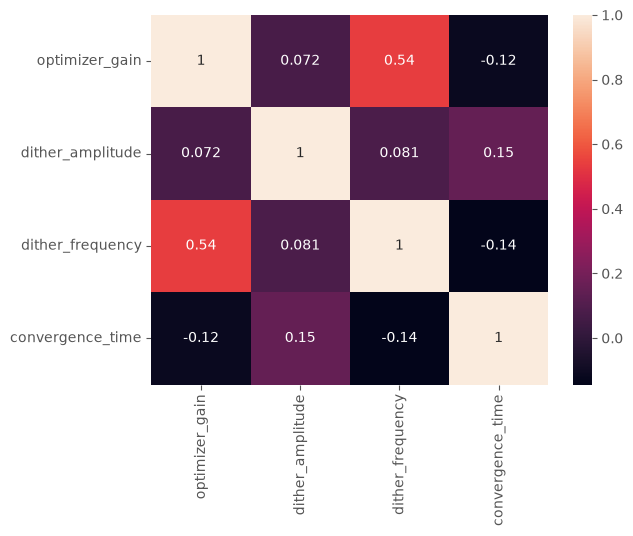

In [28]:
sns.heatmap(dfcut.drop(columns = 'converged').corr(), annot = True)


I think it would be useful to plot a 3d plot to visualize where the false predictions are.

# Visualization

In [29]:
import plotly.express as px

In [30]:
fig10k = px.scatter_3d(df,
                    x = 'optimizer_gain',
                    y = 'dither_amplitude',
                    z = 'dither_frequency',
                    color = 'convergence_time',
                    title = '3D scatter',
                    labels = {'optimizer_gain' : 'Optimizer gain',
                              'dither_amplitude' : 'Dither amplitude',
                              'dither_frequency' : 'Dither Frequency'})
fig10k.update_traces(marker=dict(size=3))
fig10k.show()

In [31]:
# Exporting the plot (put it comment as I would run the notebook all over every time I open)
# fig10k.write_html("3dscatter10k.html")

# Modelling: Classification

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score



Defining models

In [ ]:
model1 = Sequential(
    [
        Dense(32, activation='relu', name="L1"),
        Dense(16, activation='relu', name="L2"),
        Dense(1, activation = 'linear', name = "L3")  
    ]
)

model2 = Sequential(
    [
        Dense(64, activation='relu', name="L1"),
        Dense(32, activation='relu', name="L2"),
        Dense(16, activation='relu', name="L3"),
        Dense(1, activation = 'linear', name = "L4")  
    ]
)

In [ ]:
# Adding more features to the dataset
df['log10gain'] = np.log10(df['optimizer_gain'])
df['sinfre'] = np.sin(df['dither_frequency'])
df['product'] = df['optimizer_gain'] * df['dither_amplitude'] * df['sinfre']

In [ ]:
# Create training sets

X = df.drop(columns=['convergence_time', 'converged'])
y = df['converged']

# Get 60% of the dataset as the training set. Put the remaining 40% in temporary variables: x_ and y_.
X_train, X_, y_train, y_ = train_test_split(X, y, test_size=0.40, random_state=1)

# Split the 40% subset above into two: one half for cross validation and the other for the test set
X_cv, X_test, y_cv, y_test = train_test_split(X_, y_, test_size=0.50, random_state=1)

# Delete temporary variables
del X_, y_

In [21]:
# Train with model 1

model1.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.01),
)
history1 = model1.fit(X_train, 
                     y_train, 
                     epochs=300, 
                     validation_data=(X_cv, y_cv))
plt.plot(history1.history['loss'], label='train loss')
plt.plot(history1.history['val_loss'], label='cv loss')
plt.legend()
plt.show()

Epoch 1/300
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.1863 - val_loss: 0.1151
Epoch 2/300
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.1085 - val_loss: 0.1004
Epoch 3/300
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 997us/step - loss: 0.0923 - val_loss: 0.0716
Epoch 4/300
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0903 - val_loss: 0.0864
Epoch 5/300
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0852 - val_loss: 0.1782
Epoch 6/300
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 992us/step - loss: 0.0789 - val_loss: 0.1268
Epoch 7/300
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0765 - val_loss: 0.0957
Epoch 8/300
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 986us/step - loss: 0.0755 - val_loss: 0.0879
Epoch 9/300
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 980us/step - loss: 0.0759 - val_loss: 0.0670
Epoch 10/300
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0730 - val_loss: 0.0717
Epoch 11/300
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0734 - val_loss: 0.0736
Epoch 12/30

KeyboardInterrupt: 

In [ ]:
logits1 = model1.predict(X_cv)
probs1 = tf.sigmoid(logits1).numpy() # convert logit to probability
y_pred1 = (probs1 > 0.5).astype(int).flatten() # threshold at 0.5, flatten to 1D
accuracy1 = accuracy_score(y_cv, y_pred1)
print(f"CV accuracy: {accuracy1:.3f}")


In [ ]:
print(confusion_matrix(y_cv, y_pred1))
print(classification_report(y_cv, y_pred1))

In [ ]:
train_logits1 = model1.predict(X_train)
train_probs1 = tf.sigmoid(train_logits1).numpy()
train_pred1 = (train_probs1 > 0.5).astype(int).flatten()
train_acc1 = accuracy_score(y_train, train_pred1)
print(f"Train accuracy: {train_acc1:.3f}")

Try a larger model to see whether it improves accuracy.

In [ ]:
# Train with model 2

model2.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.01),
)
history2 = model2.fit(X_train, 
                     y_train, 
                     epochs=300, 
                     validation_data=(X_cv, y_cv))
plt.plot(history2.history['loss'], label='train loss')
plt.plot(history2.history['val_loss'], label='cv loss')
plt.legend()
plt.show()

In [ ]:
logits2 = model2.predict(X_cv)
probs2 = tf.sigmoid(logits2).numpy() # convert logit to probability
y_pred2 = (probs2 > 0.5).astype(int).flatten() # threshold at 0.5, flatten to 1D
accuracy2 = accuracy_score(y_cv, y_pred2)
print(f"CV accuracy: {accuracy2:.3f}")

In [ ]:
print(confusion_matrix(y_cv, y_pred2))
print(classification_report(y_cv, y_pred2))


In [ ]:
train_logits2 = model2.predict(X_train)
train_probs2 = tf.sigmoid(train_logits2).numpy()
train_pred2 = (train_probs2 > 0.5).astype(int).flatten()
train_acc2 = accuracy_score(y_train, train_pred2)
print(f"Train accuracy: {train_acc2:.3f}")

I think there is still room for improvement, but we would have to analyse the wrong predictions first.

In [ ]:
# Find where the false positives are
false_positive1 = (y_pred1 == 1) & (y_cv == 0)
X_cv1_df = pd.DataFrame(X_cv, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv1_df[false_positive1].describe())

false_positive2 = (y_pred2 == 1) & (y_cv == 0)
X_cv2_df = pd.DataFrame(X_cv, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv2_df[false_positive2].describe())

In [ ]:
# Merge the false positives into 1 table

fp1 = X_cv1_df[false_positive1]
fp2 = X_cv2_df[false_positive2]

fp = pd.concat([fp1, fp2], ignore_index=True)
print(fp.describe())

In [ ]:
# Drop duplicated rows of fp

fp = fp.loc[~fp.duplicated()].reset_index(drop = True)
print(fp.describe())

In [ ]:
# Find where the false positives are
false_positive1 = (y_pred1 == 1) & (y_cv == 0)
X_cv1_df = pd.DataFrame(X_cv, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv1_df[false_positive1].describe())

false_positive2 = (y_pred2 == 1) & (y_cv == 0)
X_cv2_df = pd.DataFrame(X_cv, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv2_df[false_positive2].describe())

       optimizer_gain  dither_amplitude  dither_frequency
count       23.000000         23.000000         23.000000
mean         0.043611          0.200512          0.519881
std          0.027565          0.133190          0.106792
min          0.003304          0.010035          0.400028
25%          0.028271          0.122738          0.429057
50%          0.036519          0.190087          0.491535
75%          0.067773          0.275431          0.574154
max          0.099766          0.456261          0.775968
       optimizer_gain  dither_amplitude  dither_frequency
count       43.000000         43.000000         43.000000
mean         0.043756          0.148359          0.552994
std          0.026655          0.111903          0.120931
min          0.003304          0.010035          0.400028
25%          0.024394          0.057972          0.450794
50%          0.036519          0.133482          0.535254
75%          0.066906          0.195307          0.638278
max          0

In [ ]:
# Merge the false positives into 1 table

fp1 = X_cv1_df[false_positive1]
fp2 = X_cv2_df[false_positive2]

fp = pd.concat([fp1, fp2], ignore_index=True)
print(fp.describe())

       optimizer_gain  dither_amplitude  dither_frequency
count       66.000000         66.000000         66.000000
mean         0.043705          0.166533          0.541455
std          0.026763          0.121337          0.116458
min          0.003304          0.010035          0.400028
25%          0.024877          0.063150          0.444814
50%          0.036519          0.165194          0.534146
75%          0.067226          0.238490          0.612596
max          0.099766          0.456261          0.799270


In [ ]:
# Drop duplicated rows of fp

fp = fp.loc[~fp.duplicated()].reset_index(drop = True)
print(fp.describe())

       optimizer_gain  dither_amplitude  dither_frequency
count       44.000000         44.000000         44.000000
mean         0.043692          0.152869          0.550257
std          0.026346          0.114569          0.120888
min          0.003304          0.010035          0.400028
25%          0.024402          0.058356          0.448607
50%          0.038736          0.136339          0.534146
75%          0.066586          0.202842          0.634853
max          0.099766          0.456261          0.799270


In [ ]:
# Find where the false negatives are
false_negative1 = (y_pred1 == 0) & (y_cv == 1)
X_cv1_df = pd.DataFrame(X_cv, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv1_df[false_negative1].describe())

false_negative2 = (y_pred2 == 0) & (y_cv == 1)
X_cv2_df = pd.DataFrame(X_cv, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv2_df[false_negative2].describe())

       optimizer_gain  dither_amplitude  dither_frequency
count       37.000000         37.000000         37.000000
mean         0.005083          0.177190          0.569160
std          0.011071          0.137042          0.118433
min          0.001109          0.015197          0.422084
25%          0.001513          0.053181          0.465095
50%          0.001974          0.177756          0.554898
75%          0.002433          0.289594          0.680075
max          0.052132          0.480833          0.797844
       optimizer_gain  dither_amplitude  dither_frequency
count      100.000000        100.000000        100.000000
mean         0.002734          0.221553          0.588241
std          0.005031          0.137472          0.112145
min          0.001109          0.010659          0.422084
25%          0.001694          0.084577          0.488461
50%          0.002198          0.229524          0.576960
75%          0.002748          0.318632          0.684867
max          0

In [ ]:
# Merge the false negatives into 1 table

fn1 = X_cv1_df[false_negative1]
fn2 = X_cv2_df[false_negative2]

fn = pd.concat([fn1, fn2], ignore_index=True)
print(fn.describe())

       optimizer_gain  dither_amplitude  dither_frequency
count      137.000000        137.000000        137.000000
mean         0.003368          0.209572          0.583088
std          0.007209          0.138272          0.113755
min          0.001109          0.010659          0.422084
25%          0.001567          0.074685          0.486353
50%          0.002152          0.214900          0.569635
75%          0.002653          0.312282          0.683960
max          0.052132          0.496698          0.797844


In [ ]:
# Drop duplicated rows of fn

fn = fn.loc[~fn.duplicated()].reset_index(drop = True)
print(fn.describe())

       optimizer_gain  dither_amplitude  dither_frequency
count      102.000000        102.000000        102.000000
mean         0.003375          0.218560          0.589149
std          0.006753          0.137762          0.111590
min          0.001109          0.010659          0.422084
25%          0.001714          0.083335          0.489185
50%          0.002207          0.226549          0.576960
75%          0.002824          0.318358          0.686681
max          0.052132          0.496698          0.797844


I realized that I did not pay enough attention to thhe dither amplitude. 
I will generate another dataset with wider range of dither amplitude (and dither frequency) to hopefully get a symmetric 3d plot.
I need to increase the range of all 3 parameters.